In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import abline_plot

In [ ]:
# Load the dataset
data = pd.read_csv("flight_purchase_new.csv")

In [ ]:
data

,frequentflyer,ID,minutes,spend
0,1,1,32,277.335449
1,1,2,9,283.324786
2,0,3,22,212.587021
3,0,4,23,242.306453
4,0,5,4,280.366660
...,...,...,...,...
495,0,496,15,196.277905
496,1,497,9,233.537740
497,0,498,5,231.816755
498,0,499,5,268.781479


# Scatterplot

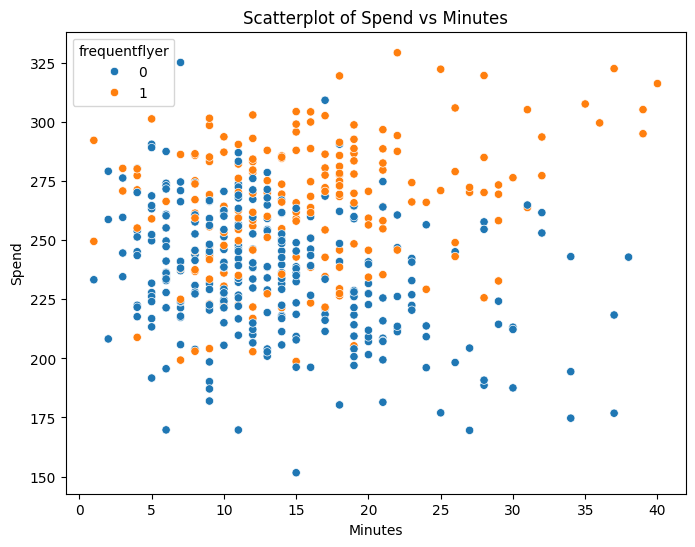

In [ ]:
# Scatterplot using seaborn
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data,
    x='minutes',
    y='spend',
    hue='frequentflyer',  # Different colors for loyalty members
)

# Add labels, title, and legend
plt.xlabel('Minutes')
plt.ylabel('Spend')
plt.title('Scatterplot of Spend vs Minutes')
plt.show()

# Linear Regression

In [ ]:
# Main effects linear regression
model_main = smf.ols('spend ~ frequentflyer + minutes', data=data).fit()
print(model_main.summary())

                            OLS Regression Results                            
Dep. Variable:                  spend   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     76.31
Date:                Tue, 25 Feb 2025   Prob (F-statistic):           1.26e-29
Time:                        19:38:25   Log-Likelihood:                -2345.3
No. Observations:                 500   AIC:                             4697.
Df Residuals:                     497   BIC:                             4709.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       237.7749      2.643     89.972

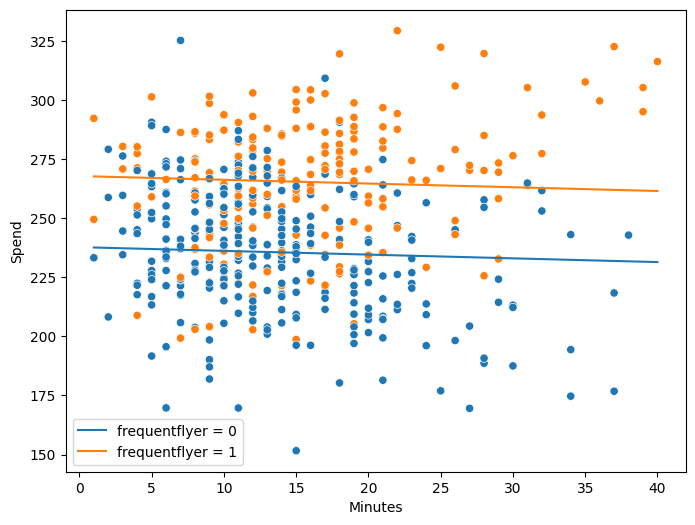

In [ ]:

# Create the plot
plt.figure(figsize=(8, 6))

# Scatterplot
sns.scatterplot(
    data=data,
    x='minutes',
    y='spend',
    hue='frequentflyer',
    legend=False  # Disable default legend for scatterplot
)

# Add regression lines

x_vals = np.linspace(data['minutes'].min(), data['minutes'].max(), 100)
for ff in [0, 1]:
    y_vals = (
        model_main.params['Intercept']
        + model_main.params['minutes'] * x_vals
        + model_main.params['frequentflyer'] * ff
    )
    plt.plot(x_vals, y_vals, label=f'frequentflyer = {ff}')


plt.legend()
plt.xlabel('Minutes')
plt.ylabel('Spend')
plt.show()

## Interaction model

In [ ]:
interaction_model = smf.ols('spend ~ frequentflyer + minutes + frequentflyer * minutes', data=data).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  spend   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     71.02
Date:                Tue, 25 Feb 2025   Prob (F-statistic):           3.18e-38
Time:                        19:38:39   Log-Likelihood:                -2322.9
No. Observations:                 500   AIC:                             4654.
Df Residuals:                     496   BIC:                             4671.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               249.86

In [ ]:
# Generate a range of values for `minutes`
x_vals = np.linspace(data['minutes'].min(), data['minutes'].max(), 100)

# Create separate predictions for each frequentflyer group
# if frequentflyer=0
pred_0 = (
    interaction_model.params['Intercept']
    + interaction_model.params['minutes'] * x_vals
)
# if frequentflyer=1
pred_1 = (
    interaction_model.params['Intercept']
    + interaction_model.params['frequentflyer']
    + (interaction_model.params['minutes'] + interaction_model.params['frequentflyer:minutes']) * x_vals
)


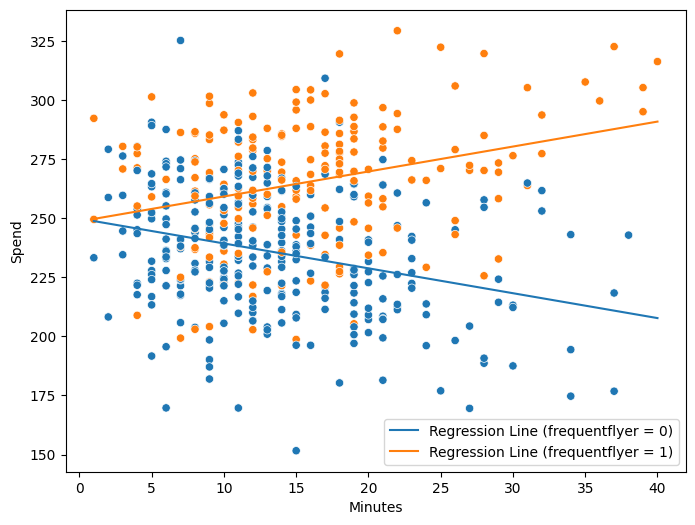

In [ ]:
plt.figure(figsize=(8, 6))

# Scatterplot for both groups
sns.scatterplot(data=data, x='minutes', y='spend', hue='frequentflyer', legend=False)

# Add regression lines
plt.plot(x_vals, pred_0,  label='Regression Line (frequentflyer = 0)')
plt.plot(x_vals, pred_1,  label='Regression Line (frequentflyer = 1)')

# Customize plot
plt.xlabel('Minutes')
plt.ylabel('Spend')
plt.legend()
plt.show()


# Interaction Model with Mean Center

In [ ]:
data['minutes_meancenter'] = data['minutes'] - data['minutes'].mean()


In [ ]:
# Fit interaction model with mean-centered predictor

interaction_centered = smf.ols('spend ~ frequentflyer + minutes_meancenter + frequentflyer:minutes_meancenter', data=data).fit()
print(interaction_centered.summary())


                            OLS Regression Results                            
Dep. Variable:                  spend   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     71.02
Date:                Tue, 25 Feb 2025   Prob (F-statistic):           3.18e-38
Time:                        19:40:16   Log-Likelihood:                -2322.9
No. Observations:                 500   AIC:                             4654.
Df Residuals:                     496   BIC:                             4671.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [ ]:

# Generate predictions
x_vals = np.linspace(data['minutes_meancenter'].min(), data['minutes_meancenter'].max(), 100)


pred_0 = (
    interaction_centered.params['Intercept']
    + interaction_centered.params['minutes_meancenter'] * x_vals
)


pred_1 = (
    interaction_centered.params['Intercept']
    + interaction_centered.params['frequentflyer']
    + (interaction_centered.params['minutes_meancenter'] + interaction_centered.params['frequentflyer:minutes_meancenter']) * x_vals
)


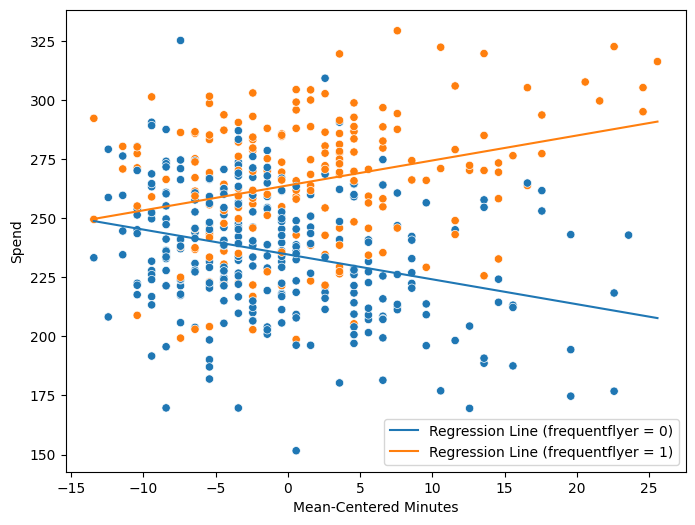

In [ ]:
plt.figure(figsize=(8, 6))

# Scatterplot for both groups
sns.scatterplot(data=data, x='minutes_meancenter', y='spend', hue='frequentflyer', legend=False)

# Add regression lines
plt.plot(x_vals, pred_0,  label='Regression Line (frequentflyer = 0)')
plt.plot(x_vals, pred_1,  label='Regression Line (frequentflyer = 1)')

# Customize plot
plt.xlabel('Mean-Centered Minutes')
plt.ylabel('Spend')
plt.legend()
plt.show()
